<a href="https://colab.research.google.com/github/ujwal-m-2006/AI-PROPERTY-URBAN-INTELLIGENCE/blob/main/colab/GBA_Property_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bengaluru & Chennai — Property & Urban Intelligence

Companion notebook to
[AI-PROPERTY-URBAN-INTELLIGENCE](https://github.com/ujwal-m-2006/AI-PROPERTY-URBAN-INTELLIGENCE).

This notebook does three things:

1. Loads all 17 platform CSVs plus both property datasets, from public URLs.
2. Reproduces the project's headline ML finding — that **most of the reported
   accuracy in a naive setup is geographic leakage**.
3. Shows the two results that are reported as failures rather than hidden.

**Nothing here is fitted to look good.** Two of the numbers you are about to see
are bad, and they are the interesting ones.

Runtime: a few minutes on a free CPU instance. No GPU, no Drive mount.

## 1 · Setup

In [1]:
import warnings, io, json, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.0.2


## 2 · Load the platform layers

All 17 CSVs come from the repository. Each file's first line is a `#` comment
carrying the caveat that constrains how the table may be read — so the loader
keeps it rather than skipping past it.

If you would rather use your own Drive folder, set `BASE` to that path instead
of the URL.

In [2]:
BASE = "https://raw.githubusercontent.com/ujwal-m-2006/AI-PROPERTY-URBAN-INTELLIGENCE/main/colab/data"          # or e.g. "/content/drive/MyDrive/colab_data"

LAYERS = [
    "gba_wards", "gba_corporations", "chennai_wards", "chennai_zones",
    "admin_taluks_bengaluru", "admin_taluks_chennai",
    "revenue_parcels", "road_network_bengaluru", "flood_locations_bengaluru",
    "localities_bengaluru", "localities_chennai",
    "amenities_bengaluru", "amenities_chennai",
    "ward_analytics_bengaluru", "ward_analytics_chennai",
    "model_comparison", "_sources",
]

def load(name):
    """Read a layer, keeping its caveat line."""
    path = f"{BASE}/{name}.csv"
    caveat = ""
    try:
        head = pd.read_csv(path, nrows=0, header=None, comment=None).columns
    except Exception:
        pass
    df = pd.read_csv(path, comment="#", low_memory=False)
    # Recover the caveat comment, which pandas skipped.
    try:
        import urllib.request
        first = urllib.request.urlopen(path).readline().decode("utf-8", "ignore")
        if first.startswith("#"):
            caveat = first.lstrip("# ").strip()
    except Exception:
        try:
            with open(path, encoding="utf-8") as fh:
                first = fh.readline()
            if first.startswith("#"):
                caveat = first.lstrip("# ").strip()
        except Exception:
            caveat = ""
    df.attrs["caveat"] = caveat
    return df

data = {}
for name in LAYERS:
    try:
        data[name] = load(name)
        print(f"  {name:<32} {len(data[name]):>6,} rows x {data[name].shape[1]:>2} cols")
    except Exception as exc:
        print(f"  {name:<32} FAILED: {type(exc).__name__}")

print(f"\n{sum(len(d) for d in data.values()):,} rows loaded across {len(data)} layers")

  gba_wards                           369 rows x 24 cols
  gba_corporations                      5 rows x 10 cols
  chennai_wards                       200 rows x 24 cols
  chennai_zones                        16 rows x  7 cols
  admin_taluks_bengaluru               24 rows x  7 cols
  admin_taluks_chennai                 30 rows x  7 cols
  revenue_parcels                   4,151 rows x 11 cols
  road_network_bengaluru           23,324 rows x 11 cols
  flood_locations_bengaluru           391 rows x  7 cols
  localities_bengaluru              1,885 rows x  5 cols
  localities_chennai                  781 rows x  5 cols
  amenities_bengaluru              13,921 rows x  8 cols
  amenities_chennai                 3,987 rows x  8 cols
  ward_analytics_bengaluru            369 rows x 27 cols
  ward_analytics_chennai              200 rows x 27 cols
  model_comparison                     12 rows x 11 cols
  _sources                             11 rows x 15 cols

49,676 rows loaded across 17 l

### The caveats are the point

Several of these tables would mislead if read at face value. They say so
themselves.

In [3]:
for name in ["gba_wards", "road_network_bengaluru", "revenue_parcels",
             "flood_locations_bengaluru", "chennai_wards"]:
    if name in data and data[name].attrs.get("caveat"):
        print(f"── {name}")
        print(f"   {data[name].attrs['caveat'][:300]}\n")

── gba_wards
   369 GBA wards. WARNING: _raw_tot_p is the source population field and sums to ~6x the real Greater Bengaluru total, with 125/369 rows failing male+female=total. Do NOT use it as population. Geometry reduced to a centroid. This row is NOT a boundary — joining on the centroid gives you a point inside 

── road_network_bengaluru
   23,324 BBMP road segments. TWO WIDTH COLUMNS: width_existing_m and width_proposed_m. The proposed figure is larger on 100% of segments (median 18 m vs 9 m) and MUST NOT be used for FAR, height or setback. Geometry reduced to a centroid. This row is NOT a boundary — joining on the centroid gives you 

── revenue_parcels
   4,151 survey parcels from digitised Bengaluru Urban revenue sheets. COVERAGE IS PARTIAL (3 taluks, 7 hoblis). A survey number here is INDICATIVE and settles nothing about boundary or title. Geometry reduced to a centroid. This row is NOT a boundary — joining on the centroid gives you a point inside 

── flood_locations_bengalur

## 3 · Provenance — where every layer came from

In [4]:
src = data["_sources"][["layer", "organisation", "tier", "availability",
                        "licence", "verification_status"]]
display(src)

print("\nTier meaning: T1 official primary · T2 official republished · "
      "T3 community/open · T4 commercial dataset")
print("No layer here is T1 — every government layer reached this project "
      "through a portal or a community mirror, and is capped accordingly.")

,layer,organisation,tier,availability,licence,verification_status
0,admin_subdistricts_bengaluru,Local Government Directory (LGD) and Survey of...,T3,DOWNLOAD,"CC0-1.0 (public domain dedication, as released)",UNVERIFIED
1,admin_subdistricts_chennai,Local Government Directory (LGD) and Survey of...,T3,DOWNLOAD,"CC0-1.0 (public domain dedication, as released)",UNVERIFIED
2,chennai_wards,Greater Chennai Corporation,T2,DOWNLOAD,As published by the OpenCity urban data portal,VERIFIED_COUNTS
3,flood_locations_bengaluru,Bruhat Bengaluru Mahanagara Palike (BBMP),T2,DOWNLOAD,Other (Public Domain) as stated by the OpenCit...,PARTIAL_COVERAGE
4,gba_wards,Greater Bengaluru Authority,T2,DOWNLOAD,Other (Public Domain) as stated by the OpenCit...,VERIFIED_COUNTS
5,locality_gazetteer_bengaluru,OpenStreetMap contributors,T3,API,Open Database License (ODbL) 1.0,COMMUNITY_SOURCED
6,locality_gazetteer_chennai,OpenStreetMap contributors,T3,API,Open Database License (ODbL) 1.0,COMMUNITY_SOURCED
7,osm_amenities,OpenStreetMap contributors,T3,API,Open Database License (ODbL) 1.0,COMMUNITY_SOURCED
8,osm_amenities_chennai,OpenStreetMap contributors,T3,API,Open Database License (ODbL) 1.0,COMMUNITY_SOURCED
9,revenue_parcels,Karnataka Revenue Department (digitised sheets),T2,DOWNLOAD,As published by the OpenCity urban data portal,PARTIAL_COVERAGE



Tier meaning: T1 official primary · T2 official republished · T3 community/open · T4 commercial dataset
No layer here is T1 — every government layer reached this project through a portal or a community mirror, and is capped accordingly.


## 4 · The two-width problem

`road_network_bengaluru` carries **two** width columns. Feeding the wrong one
into a floor-area calculation would roughly double the buildable area for the
whole city, with nothing on screen looking wrong.

,width_existing_m,width_proposed_m
min,6.0,12.0
50%,9.0,18.0
max,50.0,100.0


proposed > existing on 100.0% of 23,324 segments
A file titled 'road width map' contains a road-widening PROPOSAL.


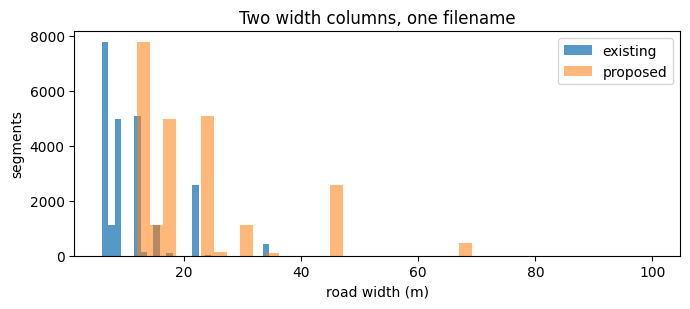

In [5]:
rd = data["road_network_bengaluru"]
w = rd[["width_existing_m", "width_proposed_m"]].describe().loc[["min", "50%", "max"]]
display(w)

larger = (rd["width_proposed_m"] > rd["width_existing_m"]).mean()
print(f"proposed > existing on {larger:.1%} of {len(rd):,} segments")
print("A file titled 'road width map' contains a road-widening PROPOSAL.")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(rd["width_existing_m"].dropna(), bins=40, alpha=.75, label="existing")
ax.hist(rd["width_proposed_m"].dropna(), bins=40, alpha=.55, label="proposed")
ax.set_xlabel("road width (m)"); ax.set_ylabel("segments"); ax.legend()
ax.set_title("Two width columns, one filename")
plt.tight_layout(); plt.show()

## 5 · The suppressed population column

`gba_wards._raw_tot_p` is the source's own population field. It sums to roughly
six times the real Greater Bengaluru total, so the platform publishes **no**
ward population at all.

Dividing by 6 reproduces the officially reported per-corporation averages almost
exactly — including East's distinctly lower figure, which nothing was fitted to.
That is suggestive, and it is still not enough.

In [6]:
gw = data["gba_wards"]
print(f"sum of _raw_tot_p : {gw['_raw_tot_p'].sum():,}")
print(f"real Greater Bengaluru population is roughly 14,000,000")
print(f"sum / 6           : {gw['_raw_tot_p'].sum()/6:,.0f}\n")

by_corp = gw.groupby("corporation")["_raw_tot_p"].agg(["count", "mean"])
by_corp["mean_div_6"] = (by_corp["mean"] / 6).round(0)
by_corp["reported"] = by_corp.index.map(
    {"Central": 40000, "East": 26000, "North": 40000,
     "South": 40000, "West": 40000})
display(by_corp)

inconsistent = (gw["_raw_tot_m"] + gw["_raw_tot_f"] != gw["_raw_tot_p"]).sum()
print(f"\nrows where male + female != total: {inconsistent} of {len(gw)}")
print("A constant chosen because it makes a total look right is not provenance,")
print("and a third of the rows fail an internal check unrelated to scale.")
print("=> the platform publishes no ward population.")

sum of _raw_tot_p : 84,028,870
real Greater Bengaluru population is roughly 14,000,000
sum / 6           : 14,004,812



,count,mean,mean_div_6,reported
corporation,,,,
Central,63,231296.190476,38549.0,40000
East,50,171089.000000,28515.0,26000
North,72,249013.888889,41502.0,40000
South,72,226083.750000,37681.0,40000
West,112,238354.732143,39726.0,40000



rows where male + female != total: 125 of 369
A constant chosen because it makes a total look right is not provenance,
and a third of the rows fail an internal check unrelated to scale.
=> the platform publishes no ward population.


## 6 · The property datasets

Fetched from their original public sources, not from this repository — the
platform never redistributes them.

* Bengaluru — **asking** prices from listings
* Chennai — **recorded sale** prices

Those targets measure different things and are never pooled.

In [7]:
blr_raw = pd.read_csv("https://raw.githubusercontent.com/dphi-official/Datasets/master/Bengaluru_House_Data.csv")
chn_raw = pd.read_csv("https://raw.githubusercontent.com/Ravi8149/Chennai-House-Price-Prediction/HEAD/chennai-house-price.csv")
print("Bengaluru", blr_raw.shape, "| Chennai", chn_raw.shape)
display(blr_raw.head(3))
display(chn_raw.head(3))

Bengaluru (13320, 9) | Chennai (7109, 22)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00


,PRT_ID,AREA,INT_SQFT,DATE_SALE,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,N_ROOM,SALE_COND,PARK_FACIL,DATE_BUILD,BUILDTYPE,UTILITY_AVAIL,STREET,MZZONE,QS_ROOMS,QS_BATHROOM,QS_BEDROOM,QS_OVERALL,REG_FEE,COMMIS,SALES_PRICE
0,P03210,Karapakkam,1004,04-05-2011,131,1.0,1.0,3,AbNormal,Yes,15-05-1967,Commercial,AllPub,Paved,A,4.0,3.9,4.9,4.330,380000,144400,7600000
1,P09411,Anna Nagar,1986,19-12-2006,26,2.0,1.0,5,AbNormal,No,22-12-1995,Commercial,AllPub,Gravel,RH,4.9,4.2,2.5,3.765,760122,304049,21717770
2,P01812,Adyar,909,04-02-2012,70,1.0,1.0,3,AbNormal,Yes,09-02-1992,Commercial,ELO,Gravel,RL,4.1,3.8,2.2,3.090,421094,92114,13159200


### Cleaning

Only what is needed to reproduce the headline result: parse the messy area
column, derive price per sq.ft, drop the extreme tail.

In [8]:
def parse_sqft(v):
    """total_sqft holds ranges ('1133 - 1384') and units ('34.46Sq. Meter')."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if "-" in s:
        parts = s.split("-")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        pass
    import re
    m = re.match(r"([\d.]+)\s*(\D+)", s)
    if not m:
        return np.nan
    n, unit = float(m.group(1)), m.group(2).lower()
    factor = {"sq. meter": 10.7639, "sq. yards": 9.0, "perch": 272.25,
              "acres": 43560.0, "cents": 435.6, "guntha": 1089.0,
              "grounds": 2400.0}
    for k, f in factor.items():
        if k in unit:
            return n * f
    return np.nan

blr = blr_raw.copy()
blr["sqft"] = blr["total_sqft"].apply(parse_sqft)
blr["rooms"] = blr["size"].astype(str).str.extract(r"(\d+)").astype(float)
blr["price_inr"] = blr["price"] * 1e5                 # source is in lakh
blr["price_per_sqft"] = blr["price_inr"] / blr["sqft"]
blr["locality"] = blr["location"].astype(str).str.strip()
blr = blr.dropna(subset=["price_per_sqft", "sqft", "rooms", "locality"])
lo, hi = blr["price_per_sqft"].quantile([0.01, 0.99])
blr = blr[(blr["price_per_sqft"] >= lo) & (blr["price_per_sqft"] <= hi)]
blr = blr[(blr["sqft"] > 100) & (blr["sqft"] < 30000)]

print(f"Bengaluru after cleaning: {len(blr):,} rows, "
      f"{blr['locality'].nunique()} localities")
print(f"  median asking: Rs {blr['price_per_sqft'].median():,.0f}/sq.ft")

Bengaluru after cleaning: 13,061 rows, 1268 localities
  median asking: Rs 5,424/sq.ft


## 7 · The headline finding — random k-fold leaks

A property and its next-door neighbour are nearly the same row. Random k-fold
puts them on opposite sides of the split, so the model memorises each locality's
price level and reports it as skill.

Grouping the folds by locality removes that. The gap is the leakage.

In [9]:
FEATURES_NUM = ["sqft", "rooms", "bath", "balcony"]
FEATURES_CAT = ["area_type", "availability"]

X = blr[FEATURES_NUM + FEATURES_CAT]
y = blr["price_per_sqft"].to_numpy()
groups = blr["locality"].to_numpy()

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), FEATURES_NUM),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore",
                                           min_frequency=10))]), FEATURES_CAT),
])

MODELS = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(n_estimators=120, random_state=42,
                                           n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}

rows = []
for name, est in MODELS.items():
    pipe = Pipeline([("pre", pre), ("m", est)])
    rand = cross_val_score(pipe, X, y, cv=KFold(5, shuffle=True,
                                                random_state=42),
                           scoring="r2", n_jobs=-1).mean()
    spat = cross_val_score(pipe, X, y, cv=GroupKFold(5), groups=groups,
                           scoring="r2", n_jobs=-1).mean()
    rows.append({"algorithm": name, "random_cv_r2": round(rand, 4),
                 "spatial_cv_r2": round(spat, 4),
                 "leakage_gap": round(rand - spat, 4)})
    print(f"  {name:<20} random {rand:.4f}   spatial {spat:.4f}   "
          f"gap {rand-spat:+.4f}")

leak = pd.DataFrame(rows)
display(leak)
print("\nEvery model scores higher under random CV. The gap is the part of the")
print("accuracy that was leakage. Model selection must use the lower number.")

  linear_regression    random 0.3480   spatial 0.3377   gap +0.0102
  random_forest        random 0.4157   spatial 0.3233   gap +0.0924
  gradient_boosting    random 0.4573   spatial 0.4381   gap +0.0192


,algorithm,random_cv_r2,spatial_cv_r2,leakage_gap
0,linear_regression,0.3480,0.3377,0.0102
1,random_forest,0.4157,0.3233,0.0924
2,gradient_boosting,0.4573,0.4381,0.0192



Every model scores higher under random CV. The gap is the part of the
accuracy that was leakage. Model selection must use the lower number.


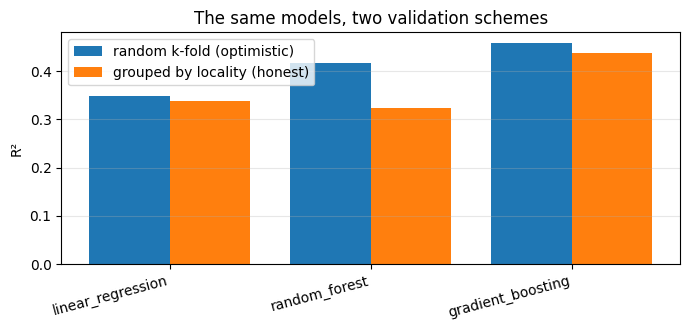

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.4))
i = np.arange(len(leak))
ax.bar(i - 0.2, leak["random_cv_r2"], 0.4, label="random k-fold (optimistic)")
ax.bar(i + 0.2, leak["spatial_cv_r2"], 0.4, label="grouped by locality (honest)")
ax.set_xticks(i); ax.set_xticklabels(leak["algorithm"], rotation=15, ha="right")
ax.set_ylabel("R²"); ax.legend(); ax.set_title("The same models, two validation schemes")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 8 · Chennai — where this would have fooled anyone

Chennai's dataset covers only **7 localities**, so there are only 7 spatial
blocks. Hold out a whole locality and the models fall apart, while a random
split reports near-perfect accuracy.

In [11]:
chn = chn_raw.copy()
chn.columns = [c.strip() for c in chn.columns]
chn["price_per_sqft"] = chn["SALES_PRICE"] / chn["INT_SQFT"]
chn["locality"] = chn["AREA"].astype(str).str.strip()
chn = chn.dropna(subset=["price_per_sqft", "INT_SQFT", "locality"])
lo, hi = chn["price_per_sqft"].quantile([0.01, 0.99])
chn = chn[(chn["price_per_sqft"] >= lo) & (chn["price_per_sqft"] <= hi)]

print(f"Chennai after cleaning: {len(chn):,} rows")
print(f"  localities (= spatial blocks): {chn['locality'].nunique()}")
print(f"  {dict(chn['locality'].value_counts())}\n")

Xc = chn[["INT_SQFT", "N_BEDROOM", "N_BATHROOM", "N_ROOM"]]
yc = chn["price_per_sqft"].to_numpy()
gc = chn["locality"].to_numpy()

pc = Pipeline([("imp", SimpleImputer(strategy="median")),
               ("sc", StandardScaler())])
for name, est in [("random_forest", RandomForestRegressor(
                       n_estimators=120, random_state=42, n_jobs=-1)),
                  ("gradient_boosting", GradientBoostingRegressor(random_state=42))]:
    pipe = Pipeline([("pre", pc), ("m", est)])
    rand = cross_val_score(pipe, Xc, yc, cv=KFold(5, shuffle=True,
                                                  random_state=42),
                           scoring="r2", n_jobs=-1).mean()
    spat = cross_val_score(pipe, Xc, yc, cv=GroupKFold(5), groups=gc,
                           scoring="r2", n_jobs=-1).mean()
    print(f"  {name:<20} random {rand:>8.4f}   spatial {spat:>8.4f}   "
          f"gap {rand-spat:+.4f}")

print("\nA negative spatial R² means the model does WORSE than predicting the")
print("mean. With 7 localities there is nothing to generalise from, and the")
print("platform refuses to quote the random-split figure as accuracy.")

Chennai after cleaning: 6,965 rows
  localities (= spatial blocks): 17
  {'Chrompet': np.int64(1636), 'Karapakkam': np.int64(1312), 'KK Nagar': np.int64(996), 'Velachery': np.int64(957), 'Anna Nagar': np.int64(783), 'Adyar': np.int64(747), 'T Nagar': np.int64(496), 'Chrompt': np.int64(9), 'Chrmpet': np.int64(6), 'Chormpet': np.int64(6), 'TNagar': np.int64(5), 'Karapakam': np.int64(3), 'Ana Nagar': np.int64(3), 'Velchery': np.int64(2), 'Ann Nagar': np.int64(2), 'Adyr': np.int64(1), 'KKNagar': np.int64(1)}

  random_forest        random   0.1419   spatial  -0.6421   gap +0.7840
  gradient_boosting    random   0.3418   spatial  -0.3077   gap +0.6495

A negative spatial R² means the model does WORSE than predicting the
mean. With 7 localities there is nothing to generalise from, and the
platform refuses to quote the random-split figure as accuracy.


## 9 · The results reported as failures

Two outputs in this project are trained, measured, and then labelled unusable.
Both are read straight from the shipped model-comparison table.

In [12]:
mc = data["model_comparison"]
display(mc.sort_values(["city", "spatial_cv_r2"], ascending=[True, False]))

print("Chennai's linear_regression scores ABOVE its tree models on spatial CV —")
print("with 7 blocks the trees overfit the blocks they saw. That inversion is")
print("why the shipped Chennai model is the simpler one.\n")

worst = mc.loc[mc["spatial_cv_r2"].idxmin()]
print(f"worst spatial R² in the project: {worst['algorithm']} on "
      f"{worst['city']} = {worst['spatial_cv_r2']}")
print("It is kept in the table rather than dropped, because a comparison that")
print("hides its failures is not a comparison.")

,city,algorithm,is_shipped_model,spatial_cv_r2,spatial_cv_mae,spatial_cv_rmse,spatial_cv_mape_pct,random_cv_r2,random_cv_mae,leakage_gap_r2,target
3,bengaluru,gradient_boosting,False,0.4231,1566.84,2404.14,27.318,0.5116,1407.08,0.0885,asking price per sq.ft (INR)
4,bengaluru,hist_gradient_boosting,True,0.4132,1593.22,2424.70,27.868,0.5473,1285.16,0.1341,asking price per sq.ft (INR)
5,bengaluru,xgboost,False,0.4121,1581.54,2426.72,27.700,0.5381,1283.28,0.1260,asking price per sq.ft (INR)
2,bengaluru,random_forest,False,0.4022,1589.48,2447.50,27.842,0.5346,1263.70,0.1324,asking price per sq.ft (INR)
1,bengaluru,linear_regression,False,0.2959,1743.46,2655.64,30.646,0.3406,1657.80,0.0447,asking price per sq.ft (INR)
0,bengaluru,baseline_median,False,-0.0653,1895.02,3266.08,28.770,-0.0623,1892.88,0.0030,asking price per sq.ft (INR)
7,chennai,linear_regression,False,0.7292,870.60,1004.82,11.400,0.9652,354.86,0.2360,recorded sale price per sq.ft (INR)
10,chennai,hist_gradient_boosting,True,0.3809,1272.24,1459.22,17.334,0.9962,100.12,0.6153,recorded sale price per sq.ft (INR)
11,chennai,xgboost,False,0.2745,1378.96,1545.06,19.020,0.9956,104.46,0.7211,recorded sale price per sq.ft (INR)
9,chennai,gradient_boosting,False,0.2293,1509.36,1685.32,19.880,0.9870,204.80,0.7577,recorded sale price per sq.ft (INR)


Chennai's linear_regression scores ABOVE its tree models on spatial CV —
with 7 blocks the trees overfit the blocks they saw. That inversion is
why the shipped Chennai model is the simpler one.

worst spatial R² in the project: baseline_median on chennai = -0.7303
It is kept in the table rather than dropped, because a comparison that
hides its failures is not a comparison.


## 10 · Ward-level service accessibility

Per-ward scores for both cities. These are **weighted formulas, not machine
learning** — no dataset carries an observed "accessibility" label to train on,
and calling a formula ML would be the easiest lie in the project.

In [13]:
for city in ["bengaluru", "chennai"]:
    wa = data.get(f"ward_analytics_{city}")
    if wa is None or wa.empty:
        continue
    cols = [c for c in wa.columns if c.endswith("_score")][:4]
    if not cols:
        cols = wa.select_dtypes("number").columns[:4].tolist()
    print(f"── {city}: {len(wa)} wards")
    display(wa[["ward_no"] + cols].describe().round(1) if "ward_no" in wa
            else wa[cols].describe().round(1))

── bengaluru: 369 wards


,ward_no,infrastructure_score
count,369.0,369.0
mean,40.3,90.6
std,26.4,4.7
min,1.0,73.0
25%,19.0,88.0
50%,37.0,92.0
75%,57.0,94.0
max,112.0,98.0


── chennai: 200 wards


,ward_no,infrastructure_score
count,200.0,200.0
mean,100.5,81.5
std,57.9,14.2
min,1.0,21.0
25%,50.8,75.0
50%,100.5,86.0
75%,150.2,91.0
max,200.0,98.0


## 11 · What this notebook did not do

Being explicit, because the omissions are deliberate:

* **No government record was fetched.** Khata, property tax, building permission
  and occupancy certificates are OTP-gated per-property portals. No public API
  exists for any of them, for anyone.
* **No ward population is published**, for the reason shown in section 5.
* **No FAR or floor limit is computed.** The governing instruments are cited in
  the platform but their clauses are not transcribed, so publishing a number
  would be a guess wearing a citation.
* **No flood risk score.** 391 reported locations with no return period, depth
  or drainage cannot support one.

The platform's value is calibrated honesty: it states what is verified, what is
indicative, and what nobody can obtain — and the last category is large.

---

Full platform, tests and data-source audit:
[github.com/ujwal-m-2006/AI-PROPERTY-URBAN-INTELLIGENCE](https://github.com/ujwal-m-2006/AI-PROPERTY-URBAN-INTELLIGENCE)